In [3]:
import pandas as pd

In [4]:
weather = pd.read_csv("weather_dataset.csv")
weather.head()

,year,month,day,max,min
0,2018,1,day1,20.836561,16.736518
1,2018,1,day10,21.856583,17.830588
2,2018,1,day11,21.834916,15.042358
3,2018,1,day12,19.041503,14.419585
4,2018,1,day13,22.743278,17.396900


In [5]:
weather.shape

(2604, 5)

In [6]:
weather

,year,month,day,max,min
0,2018,1,day1,20.836561,16.736518
1,2018,1,day10,21.856583,17.830588
2,2018,1,day11,21.834916,15.042358
3,2018,1,day12,19.041503,14.419585
4,2018,1,day13,22.743278,17.396900
...,...,...,...,...,...
2599,2024,12,day5,18.842091,11.819120
2600,2024,12,day6,15.794172,11.266991
2601,2024,12,day7,17.877106,10.198350
2602,2024,12,day8,15.809655,9.987319


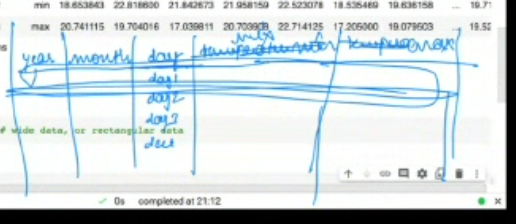

In [7]:
weather_melt = pd.melt(weather, id_vars= [ "year", "month", "element"], var_name="day", value_name="temp") ##list of variables i want to preserve 


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['element']"

In [ ]:
##i want to convert the above datas columninto two column into min , max
weather_tidy = weather_melt.pivot_table(index=["year","month", "day"], columns="element" , values="temp")

NameError: name 'weather_melt' is not defined

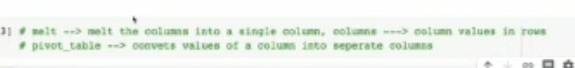

In [8]:
weather_tidy.to_csv("weather_dataset.csv", sep=',')

NameError: name 'weather_tidy' is not defined

In [9]:
data = pd.read_csv("UberDrives.csv")

In [10]:
data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [11]:
data.shape

(1156, 7)

In [12]:
data.info() ##checks type of data

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   str    
 1   END_DATE*    1155 non-null   str    
 2   CATEGORY*    1155 non-null   str    
 3   START*       1155 non-null   str    
 4   STOP*        1155 non-null   str    
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    str    
dtypes: float64(1), str(6)
memory usage: 63.3 KB


In [13]:
data.tail()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [14]:
data.drop(1155, axis=0, inplace=True) ##last row ko drop kardo row means zero axis

In [15]:
data.tail()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [16]:
data.isnull().sum(axis=0) ##no of missinf values in every columns

START_DATE*      0
END_DATE*        0
CATEGORY*        0
START*           0
STOP*            0
MILES*           0
PURPOSE*       502
dtype: int64

In [17]:
data.describe()

,MILES*
count,1155.000000
mean,10.566840
std,21.579106
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,310.300000


In [18]:
data.describe(include=object)

C:\Users\chitr\AppData\Local\Temp\ipykernel_24344\3757873171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,PURPOSE*
count,1155,1155,1155,1155,1155,653
unique,1154,1154,2,177,188,10
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,Meeting
freq,2,2,1078,201,203,187


In [19]:
##duplicates
data.loc[data.duplicated()]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
492,6/28/2016 23:34,6/28/2016 23:59,Business,Durham,Cary,9.9,Meeting


In [20]:
data.drop_duplicates(inplace=True) ##drop the duplicated row

In [21]:
data.loc[data.duplicated()]


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*


In [22]:
##removing the starts from the columns names
data.columns = [col_name[:-1] for col_name in data.columns]

In [23]:
data.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='str')

In [24]:
data

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [25]:
##hwo to handle timstamp data
data["START_DATE"] = pd.to_datetime(data["START_DATE"])
data["END_DATE"] = pd.to_datetime(data["END_DATE"])

In [26]:
data.info()

<class 'pandas.DataFrame'>
Index: 1154 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[us]
 1   END_DATE    1154 non-null   datetime64[us]
 2   CATEGORY    1154 non-null   str           
 3   START       1154 non-null   str           
 4   STOP        1154 non-null   str           
 5   MILES       1154 non-null   float64       
 6   PURPOSE     652 non-null    str           
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 72.1 KB


In [27]:
##if start time and end time is same then tha jounrnry didnot started
data.loc[data["START_DATE"] == data["END_DATE"]]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
751,2016-09-06 17:49:00,2016-09-06 17:49:00,Business,Unknown Location,Unknown Location,69.1,NaN
761,2016-09-16 07:08:00,2016-09-16 07:08:00,Business,Unknown Location,Unknown Location,1.6,NaN
798,2016-10-08 15:03:00,2016-10-08 15:03:00,Business,Karachi,Karachi,3.6,NaN
807,2016-10-13 13:02:00,2016-10-13 13:02:00,Business,Islamabad,Islamabad,0.7,NaN


In [28]:
data.loc[data["START_DATE"] == data["END_DATE"]].index ##how to get indexes 


Index([751, 761, 798, 807], dtype='int64')

In [29]:
##dropping multiple rows
data.drop([751, 761, 798, 807], inplace=True, axis=0)


In [30]:
ta = data["START_DATE"][0]
ta

Timestamp('2016-01-01 21:11:00')

In [31]:
ta.year

2016

In [32]:
ta.day

1

In [33]:
ta.day_name()

'Friday'

In [34]:
data["END_DATE"].dt.year

0       2016
1       2016
2       2016
3       2016
4       2016
        ... 
1150    2016
1151    2016
1152    2016
1153    2016
1154    2016
Name: END_DATE, Length: 1150, dtype: int32

In [35]:
data["END_DATE"].dt.month_name()

0        January
1        January
2        January
3        January
4        January
          ...   
1150    December
1151    December
1152    December
1153    December
1154    December
Name: END_DATE, Length: 1150, dtype: str

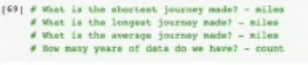

In [36]:
print(data["MILES"].min())

0.5


In [37]:
data["START_DATE"].dt.year.nunique ##nunique gives number of unique values


<bound method IndexOpsMixin.nunique of 0       2016
1       2016
2       2016
3       2016
4       2016
        ... 
1150    2016
1151    2016
1152    2016
1153    2016
1154    2016
Name: START_DATE, Length: 1150, dtype: int32>

In [38]:
data["START_DATE"].dt.year.nunique()

1

In [39]:
data["END_DATE"].dt.year.nunique()

1

In [40]:
data["START_DATE"].dt.month.nunique()

12

## Basix Discriptive Statistics

In [41]:


data["MILES"].mean()

np.float64(10.538956521739129)

In [42]:
print(data["MILES"].max())
print(data["MILES"].min())
print(data["MILES"].median()) ###better estimation thaan mean 

310.3
0.5
6.0


In [43]:
data["PURPOSE"].value_counts()

PURPOSE
Meeting            186
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

In [44]:
data["PURPOSE"].mode()

0    Meeting
Name: PURPOSE, dtype: str

## Measure Of Dispersion

In [45]:
## to quantify exactly how much data varies----

## Mean Absoltute  deaviation

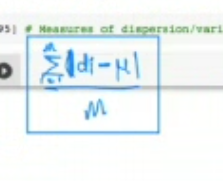 

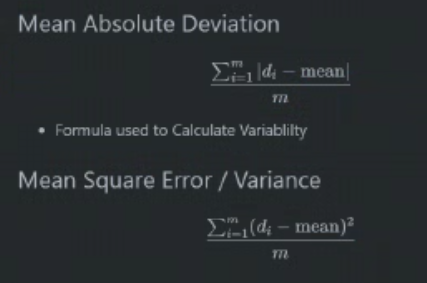

In [46]:
data["MILES"].std()

np.float64(21.55235968026448)

In [47]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [48]:
from scipy import stats

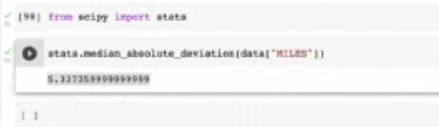

In [50]:
stats.median_abs_deviation(data["MILES"])

np.float64(3.6)

In [51]:
import numpy as np

In [ ]:
np.percentile(data["MILES"], 50) ###calculates 50 percentile of miles

np.float64(6.0)

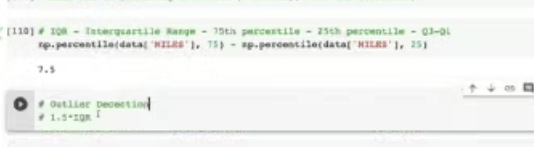